# Project Objective

The objective of this project is to analyze customer behavior and develop a machine learning model capable of predicting customer churn.

By identifying customers who are likely to leave the telecom company, businesses can implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss.

The project follows a complete machine learning workflow including:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Model Building
- Model Evaluation
- Business Recommendations

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv('customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(" " ,"0")
df['TotalCharges'] = df['TotalCharges'].astype("float64")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [77]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [78]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

In [79]:
df.head(40)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [80]:
df['SeniorCitizen'].dtype

dtype('int64')

In [81]:
df['SeniorCitizen'].unique()

array([0, 1])

In [82]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [83]:
df['SeniorCitizen'].head()

0    No
1    No
2    No
3    No
4    No
Name: SeniorCitizen, dtype: object

In [18]:
df.head(30)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


#converted 0 and 1 values to senior citizen yes/no for easier understanding

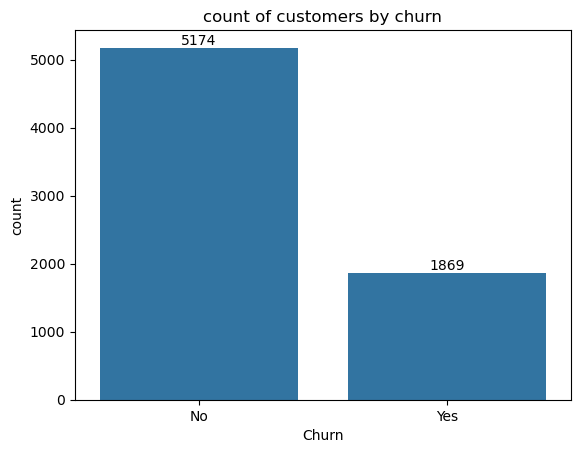

In [19]:
ax = sns.countplot(x='Churn' , data = df)
ax.bar_label(ax.containers[0])
plt.title("count of customers by churn")
plt.show()

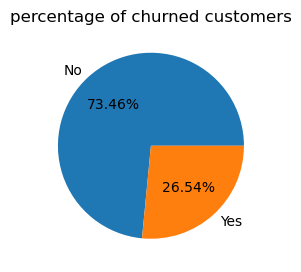

In [20]:
plt.figure(figsize = (3,4))
gb = df.groupby('Churn').agg({'Churn' :"count"})
plt.pie(gb['Churn'],labels=gb.index,autopct = '%1.2f%%')
plt.title("percentage of churned customers")
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out

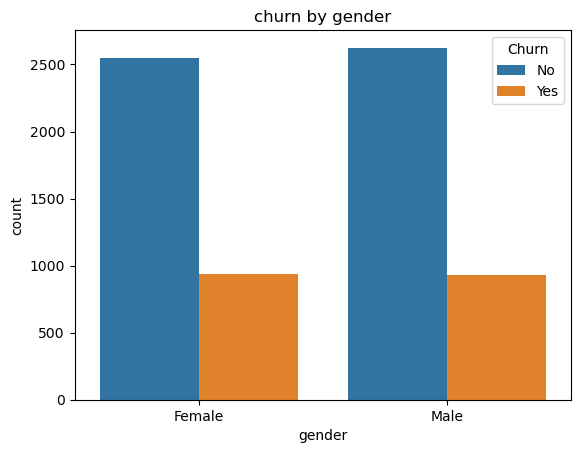

In [21]:
sns.countplot(x="gender",data=df,hue = "Churn")
plt.title("churn by gender")
plt.show()

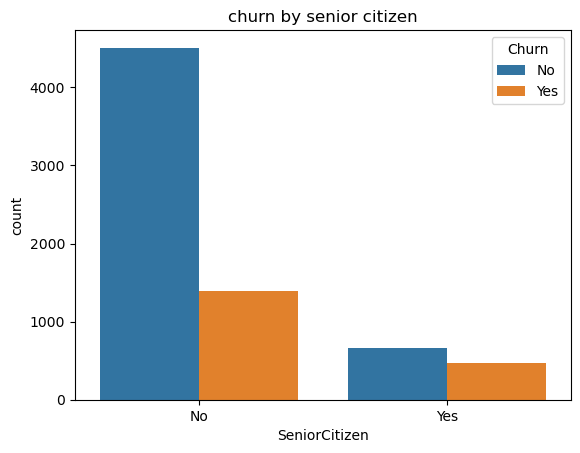

In [22]:
sns.countplot(x="SeniorCitizen",data=df,hue = "Churn")
plt.title("churn by senior citizen")
plt.show()

#comparatively a greater percentage of people in the senior citizen category have churned out


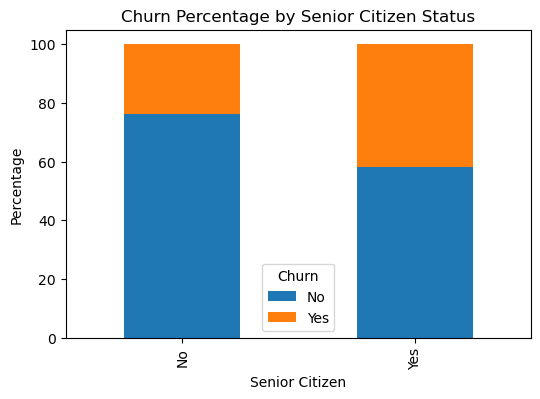

In [23]:
# Convert counts to percentages
ct_pct = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

# Plot
ct_pct.plot(kind='bar', stacked=True, figsize=(6,4))

plt.title("Churn Percentage by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

In [24]:
#comparatively a greater percentage of people in the senior citizen category have churned out

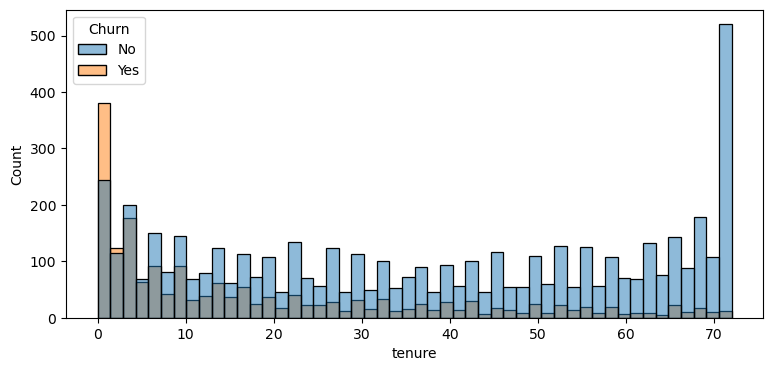

In [25]:
plt.figure(figsize = (9,4))
sns.histplot(x='tenure' , data = df , bins = 50,hue = 'Churn')
plt.show()

#people who have used our services for a long time have stayed and people who have used our services for 1 or 2 months have churned

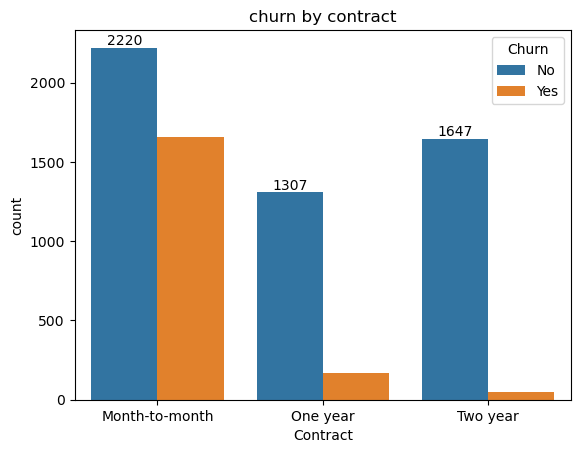

In [26]:
ax = sns.countplot(x="Contract",data=df,hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("churn by contract")
plt.show()

#people who have month to month contract are likely to churn than those who have 1 or 2 year contract

In [27]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

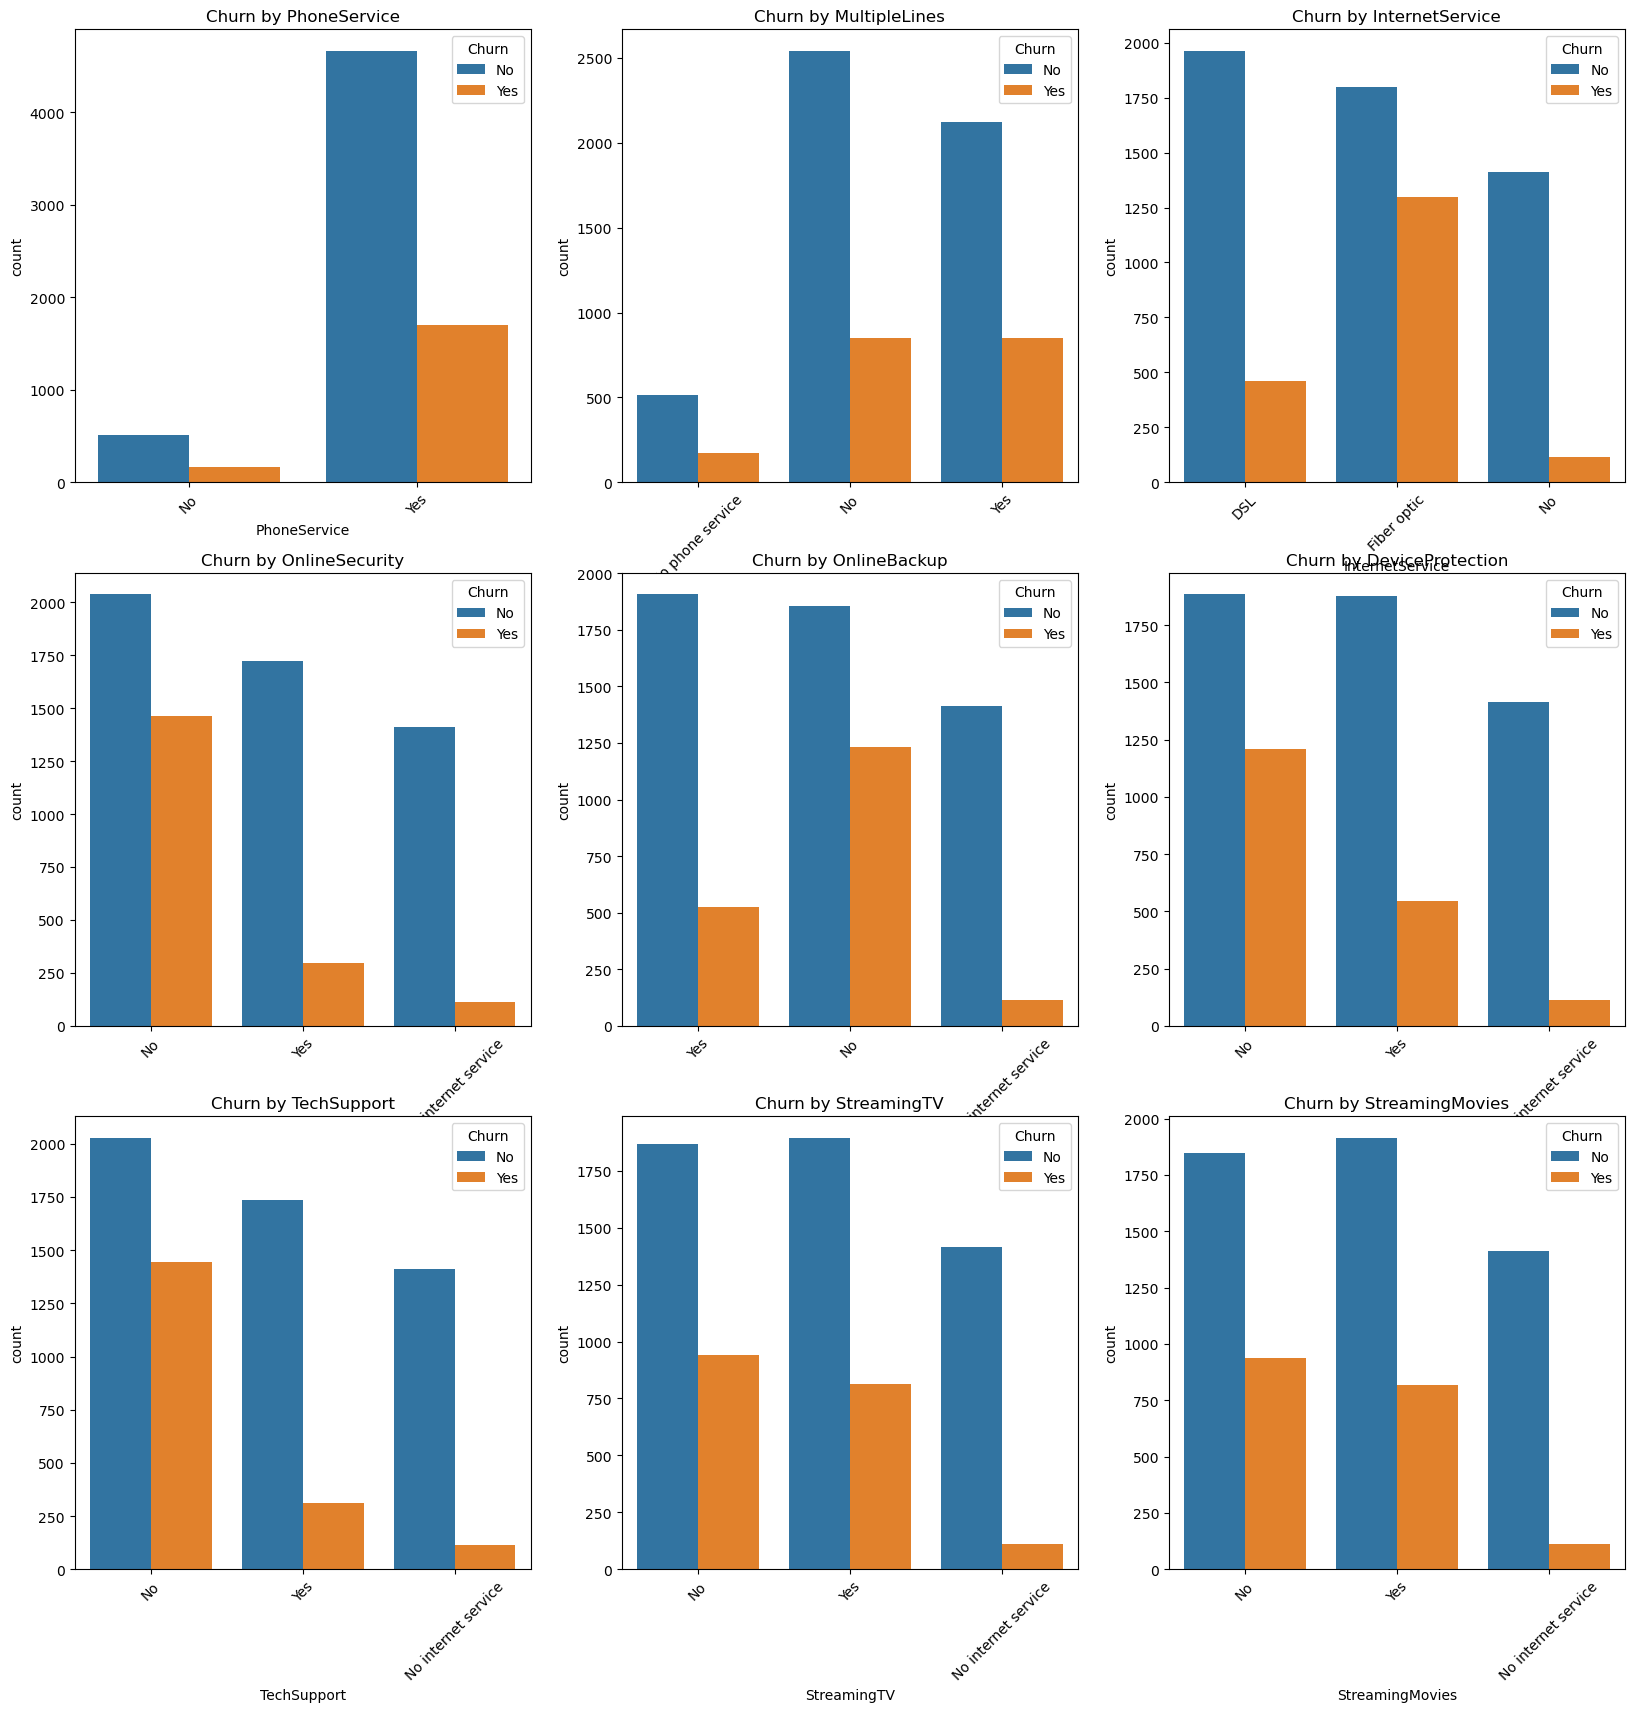

In [28]:
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(20,20))

for i, col in enumerate(columns):
    row = i // 3
    col_num = i % 3

    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        ax=axes[row, col_num]
    )

    axes[row, col_num].set_title(f'Churn by {col}')
    axes[row, col_num].tick_params(axis='x', rotation=45)


plt.show()

#Fiber Optic customers have the highest churn rate.
Customers without Online Security, Online Backup, Device Protection, and Tech Support are more likely to churn.
Streaming TV and Streaming Movies have little impact on customer churn.
Phone Service and Multiple Lines do not significantly affect churn.

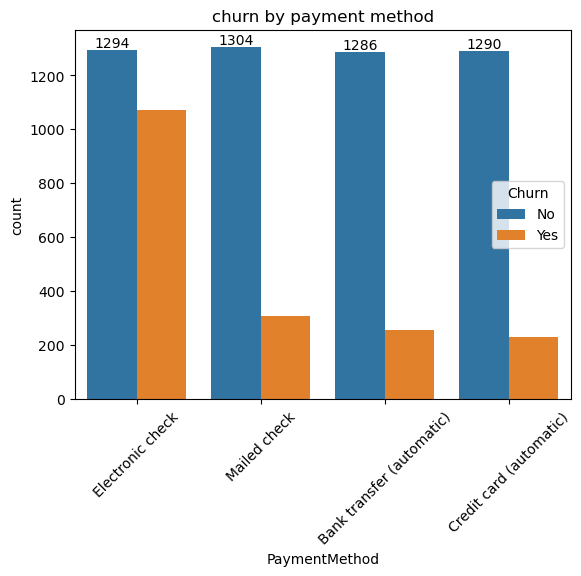

In [29]:
ax = sns.countplot(x="PaymentMethod",data=df,hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("churn by payment method")
plt.xticks(rotation = 45)
plt.show()

customer is likely to churn when he is using electronic check as payment method

# Part 2: Machine Learning

The Exploratory Data Analysis (EDA) provided valuable insights into the factors affecting customer churn. In this section, we will build machine learning models to predict whether a customer is likely to churn based on their demographic information, services subscribed, billing details, and account history.

Machine Learning Workflow:

1. Data Preprocessing
2. Feature Engineering
3. Train-Test Split
4. Model Building
5. Model Evaluation
6. Model Comparison
7. Business Recommendations

## Step 1: Create a Copy of the Dataset

Before applying any preprocessing techniques, we create a copy of the cleaned dataset. This ensures that the original dataset used for EDA remains unchanged.

In [32]:
df_model = df.copy()
print(df_model.shape)
df_model.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Remove Unnecessary Columns

The customerID column is only a unique identifier assigned to each customer.

Since every customer has a different ID, this column does not provide any meaningful information for predicting churn.

Keeping it may even reduce the model's performance.

Therefore, it will be removed.

In [33]:
df_model.drop("customerID",axis=1,inplace = True)
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Check Data Types

Machine Learning algorithms require numerical input.

Before converting categorical variables, we first inspect the datatype of every column.

In [34]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## Step 4: Convert Target Variable

The target variable (Churn) contains categorical values:

No

Yes

Since machine learning models cannot learn from text labels, these values are converted into numerical values.

No  → 0

Yes → 1

In [35]:
df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})
df_model["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [36]:
df_model["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Step 5: Identify Categorical Features

The dataset contains several categorical variables such as Gender, Contract Type, Internet Service, and Payment Method.

These variables must be converted into numerical form before training the machine learning model.

We first identify all categorical columns.

In [37]:
categorical_columns = df_model.select_dtypes(include="object").columns

categorical_columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

## Step 6: One-Hot Encoding

Most categorical variables in this dataset are nominal, meaning they have no natural order.

Using Label Encoding may incorrectly introduce an ordinal relationship between categories.

Therefore, One-Hot Encoding is used.

The parameter drop_first=True is used to avoid multicollinearity (Dummy Variable Trap).

In [38]:
df_model = pd.get_dummies(
    df_model,
    drop_first=True,
    dtype=int
)

df_model.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,1,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,2,70.70,151.65,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [39]:
print(df_model.shape)

(7043, 31)


After One-Hot Encoding, every categorical feature is converted into one or more binary columns.

For example->

Contract,
Month-to-month,
One year,
Two year

becomes

Contract_One year,
Contract_Two year

The model can now interpret these features numerically.

## Step 7: Separate Features and Target Variable

The dataset is divided into:

Features (X)

Target Variable (y)

Features contain all independent variables.

Target contains the value to be predicted.

In [40]:
X = df_model.drop("Churn", axis=1)

y = df_model["Churn"]

print(X.shape)

print(y.shape)

(7043, 30)
(7043,)


## Step 8: Split the Dataset into Training and Testing Sets

Machine Learning models are trained on one portion of the dataset and evaluated on another unseen portion.

This helps us measure how well the model generalizes to new data.

We will use:

- 80% of the data for training
- 20% of the data for testing

The random_state parameter ensures reproducibility of the results.

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 30)
Testing Features  : (1409, 30)
Training Labels   : (5634,)
Testing Labels    : (1409,)


### Verify Class Distribution

After splitting the dataset, we verify that both the training and testing datasets maintain a similar distribution of the target classes.

This ensures that the model learns and is evaluated on representative samples.

In [44]:
print("Training Set")

print(y_train.value_counts(normalize=True))

print()

print("Testing Set")

print(y_test.value_counts(normalize=True))

Training Set
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Set
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Step 9: Feature Scaling

Many machine learning algorithms calculate distances between data points.

Features like MonthlyCharges and Tenure have different numerical ranges.

Without scaling, features with larger values may dominate the learning process.

StandardScaler standardizes every numerical feature so that:

Mean = 0

Standard Deviation = 1

Although tree-based models do not require scaling, algorithms such as Logistic Regression, K-Nearest Neighbors, and Support Vector Machines perform significantly better after feature scaling.

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()

In [47]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [48]:
print("Original Shape :", X_train.shape)

print("Scaled Shape   :", X_train_scaled.shape)

Original Shape : (5634, 30)
Scaled Shape   : (5634, 30)


## Step 10: Build the First Machine Learning Model

We begin with Logistic Regression.

Logistic Regression is a simple yet powerful classification algorithm commonly used as a baseline model.

Advantages:

- Fast to train
- Easy to interpret
- Performs well on binary classification problems
- Provides probability estimates

In [49]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Step 11: Make Predictions

After training the model, we use the unseen testing data to predict whether each customer is likely to churn.

In [50]:
y_pred = log_model.predict(X_test_scaled)

In [51]:
y_pred[:20]
y_pred_proba = log_model.predict_proba(X_test_scaled)
y_pred_proba[:5]

array([[0.95501784, 0.04498216],
       [0.31676582, 0.68323418],
       [0.94345828, 0.05654172],
       [0.59219449, 0.40780551],
       [0.97833433, 0.02166567]])

## Step 12: Evaluate the Logistic Regression Model

Training a model is only half the task.

The next step is to evaluate how well the model performs on unseen data.

In this section, we will evaluate the model using:

- Accuracy Score
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics provide a comprehensive understanding of the model's performance.

In [52]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

### Accuracy Score

Accuracy measures the percentage of correctly classified observations.

Formula:

Accuracy = (Correct Predictions) / (Total Predictions)

Although accuracy is easy to understand, it may be misleading for imbalanced datasets.

Therefore, additional evaluation metrics are also considered.

In [53]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8070


### Precision, Recall and F1-Score

Precision:
Out of all customers predicted to churn, how many actually churned?

Recall:
Out of all customers who actually churned, how many did the model correctly identify?

F1-Score:
The harmonic mean of Precision and Recall.

These metrics become especially important in churn prediction because identifying customers likely to leave is often more valuable than simply maximizing overall accuracy.

In [54]:
precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.6584
Recall    : 0.5668
F1 Score  : 0.6092


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Confusion Matrix

A Confusion Matrix summarizes the prediction results by comparing actual and predicted classes.

It contains four values:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

This helps us understand the types of mistakes made by the model.

In [56]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[925, 110],
       [162, 212]])

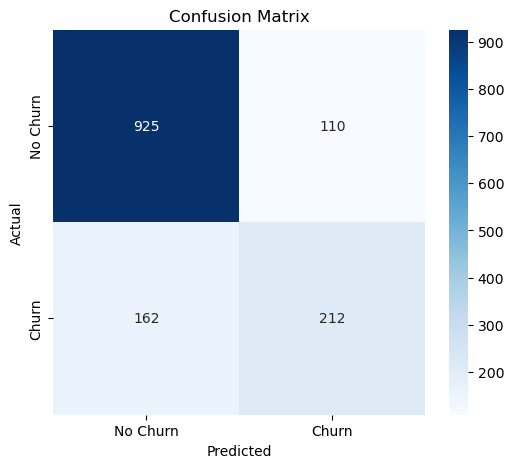

In [57]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### ROC-AUC Score

The ROC-AUC score measures the model's ability to distinguish between churn and non-churn customers.

A higher ROC-AUC score indicates better classification performance.

An ROC-AUC score closer to 1 represents an excellent model.

In [58]:
roc_auc = roc_auc_score(
    y_test,
    y_pred_proba[:,1]
)

print(f"ROC AUC Score : {roc_auc:.4f}")

ROC AUC Score : 0.8418


In [59]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba[:,1]
)

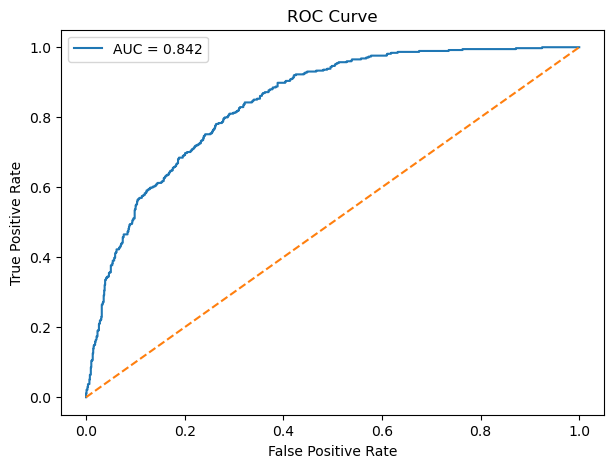

In [60]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Logistic Regression Performance Summary

The Logistic Regression model serves as a strong baseline classifier.

Based on the evaluation metrics, it provides a balanced trade-off between accuracy and interpretability.

However, more advanced models such as Decision Tree, Random Forest, Gradient Boosting, and K-Nearest Neighbors may capture complex patterns more effectively.

In the next section, multiple machine learning models will be trained and compared to identify the best-performing model.

# Part 3: Model Comparison

Logistic Regression provides a strong baseline model.

However, different machine learning algorithms learn patterns differently.

To identify the best-performing model for predicting customer churn, we will train and compare multiple classification algorithms.

The following models will be evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Gradient Boosting

Each model will be evaluated using the same testing dataset to ensure a fair comparison.

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [63]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

## Evaluate Every Model

Each model is evaluated using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

The results are stored in a dataframe for easy comparison.

In [64]:
results = []

In [65]:
for name, model in models.items():

    # Scale only for models that need it
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

        probabilities = model.predict_proba(X_test_scaled)[:, 1]

    else:
        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

In [66]:
comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
1,Decision Tree,0.742370,0.515493,0.489305,0.502058,0.661067
2,Random Forest,0.790632,0.636678,0.491979,0.555053,0.827331
3,KNN,0.747339,0.525281,0.500000,0.512329,0.771797
4,Gradient Boosting,0.798439,0.655172,0.508021,0.572289,0.842174


In [67]:
comparison_df = comparison_df.sort_values(
    by="ROC AUC",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,Gradient Boosting,0.798439,0.655172,0.508021,0.572289,0.842174
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
2,Random Forest,0.790632,0.636678,0.491979,0.555053,0.827331
3,KNN,0.747339,0.525281,0.500000,0.512329,0.771797
1,Decision Tree,0.742370,0.515493,0.489305,0.502058,0.661067


## Visual Comparison of Model Accuracy

A bar chart provides a quick comparison of the predictive performance of each machine learning model.

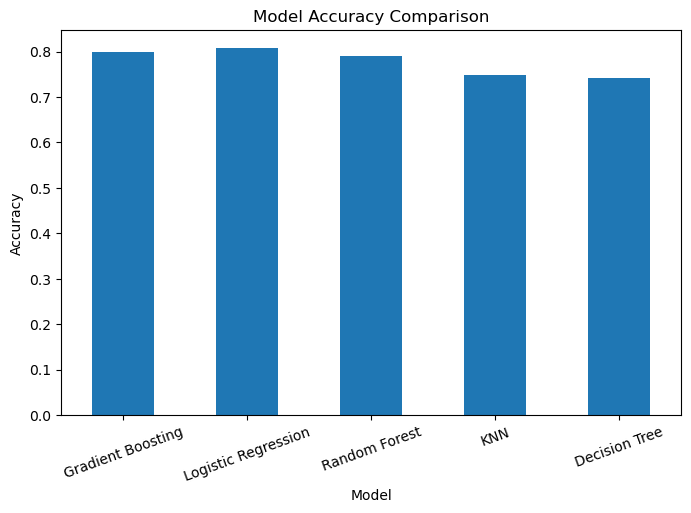

In [68]:
comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

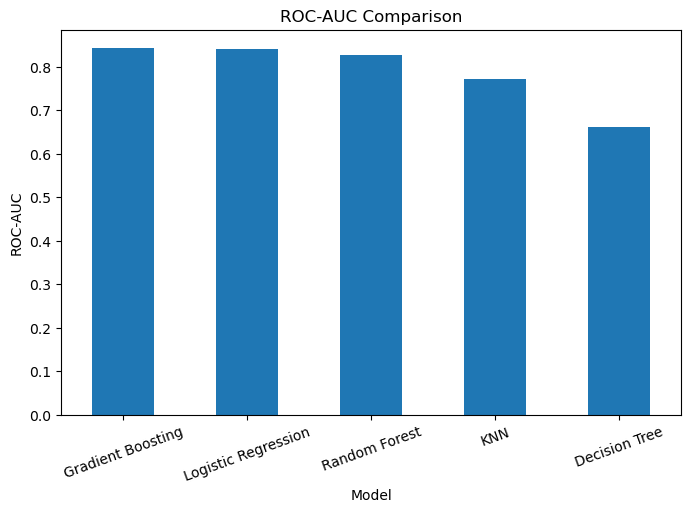

In [69]:
comparison_df.plot(
    x="Model",
    y="ROC AUC",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("ROC-AUC Comparison")

plt.ylabel("ROC-AUC")

plt.xticks(rotation=20)

plt.show()

## Best Performing Model

Based on the evaluation metrics, the model with the highest ROC-AUC score will be selected for further optimization.

ROC-AUC is chosen because it evaluates how effectively the model distinguishes between customers who churn and those who do not.

This metric is particularly useful for classification problems with moderately imbalanced datasets.

In [70]:
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,Gradient Boosting,0.798439,0.655172,0.508021,0.572289,0.842174
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
2,Random Forest,0.790632,0.636678,0.491979,0.555053,0.827331
3,KNN,0.747339,0.525281,0.500000,0.512329,0.771797
1,Decision Tree,0.742370,0.515493,0.489305,0.502058,0.661067


In [71]:
comparison_df.style.highlight_max(subset=["Accuracy"], color="lightgreen") \
                   .highlight_max(subset=["ROC AUC"], color="lightblue")

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,Gradient Boosting,0.798439,0.655172,0.508021,0.572289,0.842174
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
2,Random Forest,0.790632,0.636678,0.491979,0.555053,0.827331
3,KNN,0.747339,0.525281,0.500000,0.512329,0.771797
1,Decision Tree,0.742370,0.515493,0.489305,0.502058,0.661067


In [72]:
best_model = comparison_df.iloc[0]

print("Best Performing Model")
print("-" * 30)
print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")
print(f"ROC AUC    : {best_model['ROC AUC']:.4f}")

Best Performing Model
------------------------------
Model      : Gradient Boosting
Accuracy   : 0.7984
Precision  : 0.6552
Recall     : 0.5080
F1 Score   : 0.5723
ROC AUC    : 0.8422


# Final Conclusion

This project successfully developed a machine learning solution to predict customer churn using the Telecom Customer Churn dataset.

The project followed a complete machine learning workflow, including data cleaning, exploratory data analysis (EDA), feature engineering, data preprocessing, model training, model evaluation, and model comparison.

Five classification algorithms were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Gradient Boosting

The models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

Among all the evaluated models, **Gradient Boosting** achieved the highest ROC-AUC Score (0.8422), indicating the strongest ability to distinguish between customers who are likely to churn and those who are not. Therefore, Gradient Boosting was selected as the final model for this project.

The results demonstrate that machine learning can effectively predict customer churn and assist telecom companies in identifying high-risk customers before they leave, enabling proactive customer retention strategies.

# Business Recommendations

Based on the exploratory data analysis and machine learning results, the following recommendations can help reduce customer churn:

- Encourage customers with Month-to-Month contracts to switch to long-term plans through discounts and loyalty programs.

- Focus retention efforts on customers with shorter tenure by providing personalized onboarding experiences and early engagement programs.

- Monitor customers with higher monthly charges and offer customized pricing plans or promotional benefits to improve customer satisfaction.

- Improve the quality and reliability of internet services associated with higher churn rates and strengthen customer support.

- Deploy the developed Gradient Boosting model to identify customers who are at a high risk of churning and proactively target them with personalized retention campaigns.

Implementing these recommendations can improve customer retention, enhance customer satisfaction, and reduce revenue loss caused by customer churn.

# Thank You

This project demonstrated the complete workflow of a supervised machine learning classification problem, from raw data analysis to predictive model development.

The developed model can assist telecom companies in identifying customers who are likely to churn and support data-driven customer retention strategies.

Future improvements may include hyperparameter tuning, cross-validation, model deployment, and real-time prediction using a web application.